**dataset creation file**

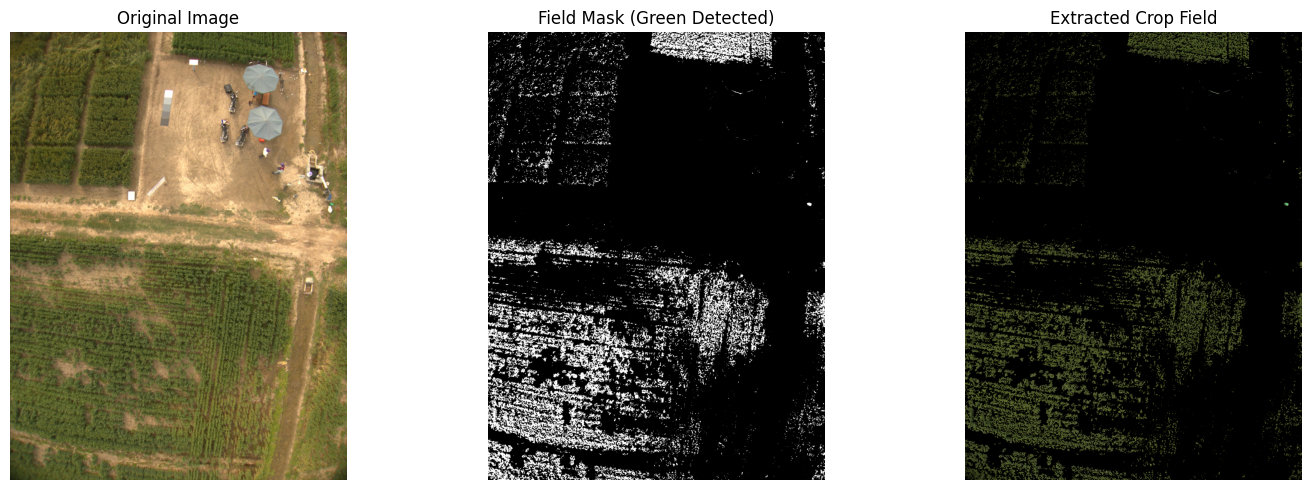

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

field_mask = cv2.inRange(hsv, lower_green, upper_green)


field_mask_binary = field_mask / 255


overlay = image.copy()
overlay[field_mask == 0] = [0, 0, 0]  # remove non-field

plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

# Field Mask
plt.subplot(1,3,2)
plt.title("Field Mask (Green Detected)")
plt.imshow(field_mask, cmap='gray')
plt.axis("off")

# Overlay Result
plt.subplot(1,3,3)
plt.title("Extracted Crop Field")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

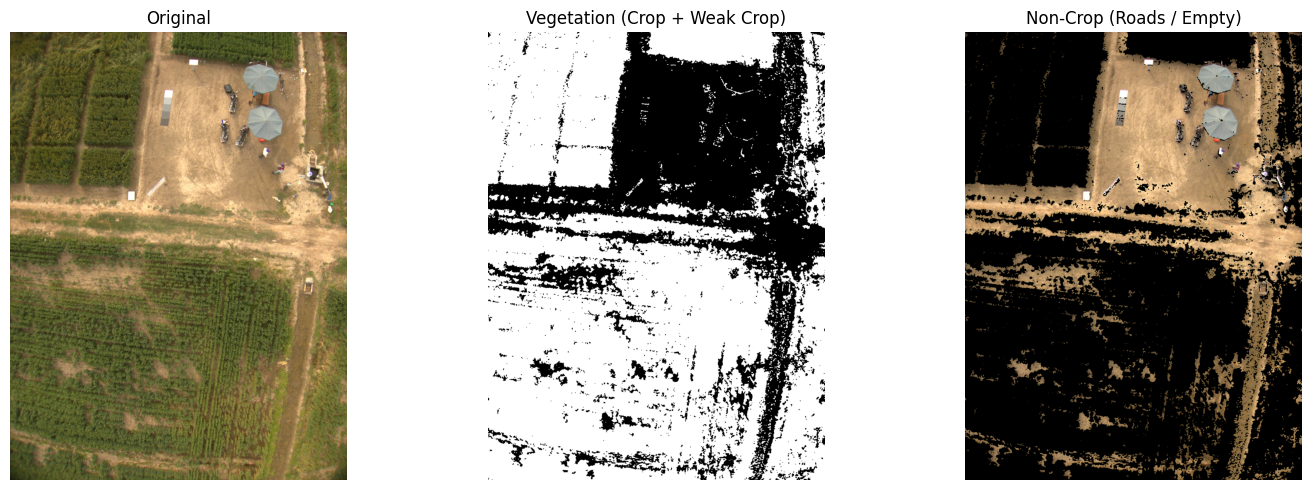

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# BROADER vegetation mask (IMPORTANT)
lower_veg = np.array([20, 30, 30])   # includes yellow + green
upper_veg = np.array([100, 255, 255])

veg_mask = cv2.inRange(hsv, lower_veg, upper_veg)

# Clean mask
kernel = np.ones((5,5), np.uint8)
veg_mask = cv2.morphologyEx(veg_mask, cv2.MORPH_CLOSE, kernel)
veg_mask = cv2.morphologyEx(veg_mask, cv2.MORPH_OPEN, kernel)

# Invert → NON-CROP (roads, empty areas)
non_crop_mask = cv2.bitwise_not(veg_mask)

# Extract non-crop area
non_crop = image.copy()
non_crop[veg_mask != 0] = [0, 0, 0]

# Visualization
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Vegetation (Crop + Weak Crop)")
plt.imshow(veg_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Non-Crop (Roads / Empty)")
plt.imshow(non_crop)
plt.axis("off")

plt.tight_layout()
plt.show()

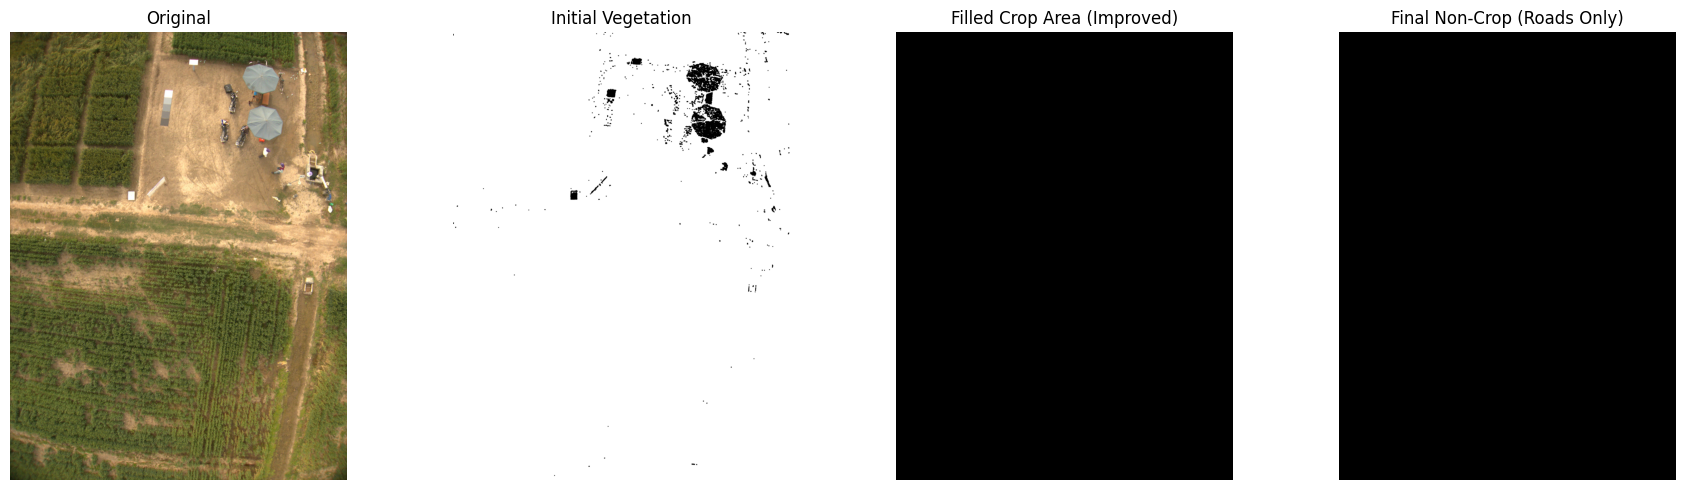

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)


lower_veg = np.array([15, 20, 20])
upper_veg = np.array([110, 255, 255])

veg_mask = cv2.inRange(hsv, lower_veg, upper_veg)


kernel = np.ones((7,7), np.uint8)
veg_mask = cv2.morphologyEx(veg_mask, cv2.MORPH_CLOSE, kernel)

h, w = veg_mask.shape
mask_floodfill = veg_mask.copy()
mask_temp = np.zeros((h+2, w+2), np.uint8)

cv2.floodFill(mask_floodfill, mask_temp, (0,0), 255)

# Invert floodfilled image
mask_floodfill_inv = cv2.bitwise_not(mask_floodfill)

# Combine with original
veg_mask_filled = veg_mask | mask_floodfill_inv

# Step 4: Clean again
veg_mask_filled = cv2.morphologyEx(veg_mask_filled, cv2.MORPH_OPEN, kernel)

# Step 5: Extract NON-CROP (roads + empty)
non_crop_mask = cv2.bitwise_not(veg_mask_filled)

non_crop = image.copy()
non_crop[veg_mask_filled != 0] = [0, 0, 0]

# Visualization
plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Initial Vegetation")
plt.imshow(veg_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Filled Crop Area (Improved)")
plt.imshow(veg_mask_filled, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Final Non-Crop (Roads Only)")
plt.imshow(non_crop)
plt.axis("off")

plt.tight_layout()
plt.show()

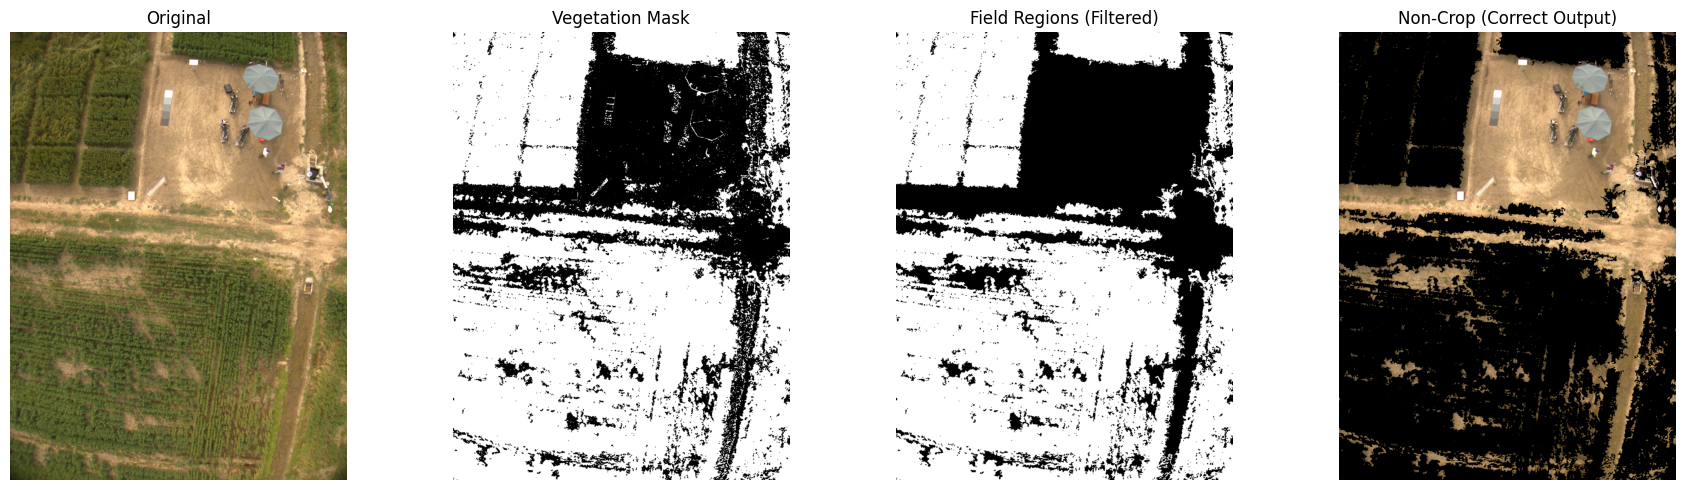

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# Step 1: Loose vegetation mask
lower_veg = np.array([20, 30, 30])
upper_veg = np.array([110, 255, 255])

veg_mask = cv2.inRange(hsv, lower_veg, upper_veg)

# Step 2: Clean noise
kernel = np.ones((5,5), np.uint8)
veg_mask = cv2.morphologyEx(veg_mask, cv2.MORPH_CLOSE, kernel)

# Step 3: Connected Components (KEY STEP 🔥)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(veg_mask)

# Create final field mask
field_mask = np.zeros_like(veg_mask)

# Keep only LARGE regions (fields)
min_area = 5000   # 🔥 tune this

for i in range(1, num_labels):  # skip background
    area = stats[i, cv2.CC_STAT_AREA]
    if area > min_area:
        field_mask[labels == i] = 255

# Step 4: Extract non-crop (roads + gaps)
non_crop = image.copy()
non_crop[field_mask != 0] = [0, 0, 0]

# Visualization
plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Vegetation Mask")
plt.imshow(veg_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Field Regions (Filtered)")
plt.imshow(field_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Non-Crop (Correct Output)")
plt.imshow(non_crop)
plt.axis("off")

plt.tight_layout()
plt.show()

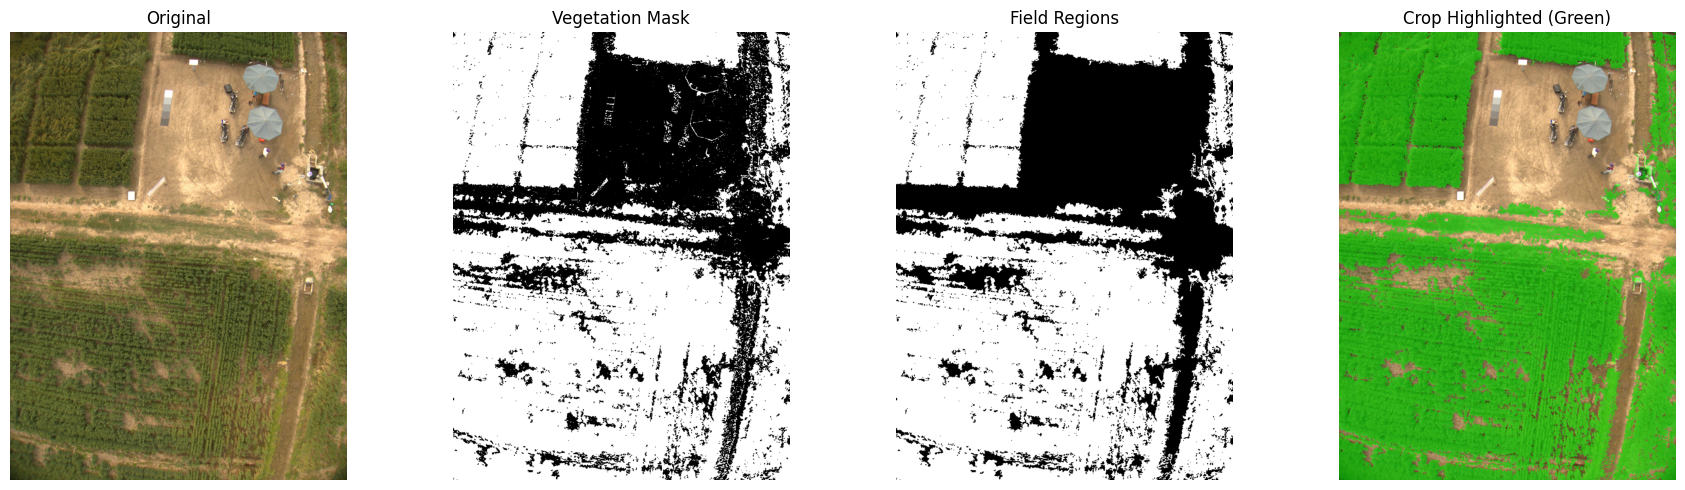

In [ ]:
# Step 4: Create GREEN overlay for crop area
overlay = image.copy()

# Create green color mask
green_layer = np.zeros_like(image)
green_layer[:, :] = [0, 255, 0]  # pure green

# Blend only on crop regions
alpha = 0.5  # transparency (adjust 0.3–0.7)

mask_bool = field_mask == 255

overlay[mask_bool] = cv2.addWeighted(
    image[mask_bool],
    1 - alpha,
    green_layer[mask_bool],
    alpha,
    0
)

# Visualization
plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Vegetation Mask")
plt.imshow(veg_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Field Regions")
plt.imshow(field_mask, cmap='gray')
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Crop Highlighted (Green)")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/dataset.zip

Archive:  /content/drive/MyDrive/dataset.zip
   creating: images/
   creating: masks/
  inflating: images/IMG_2663_jpeg.rf.d13c07c0e4dfb84ab9e4ac6234b8f81a.jpg  
  inflating: images/IMG_2801_jpeg.rf.40e36a71000e6666a6e97a4fae2f56c1.jpg  
  inflating: images/IMG_2905_jpeg.rf.11e14ec8f4a5082c0751e9ad04b48163.jpg  
  inflating: images/IMG_2828_jpeg.rf.81e16f3e578160b9ca3855a3290931eb.jpg  
  inflating: images/IMG_2960_jpeg.rf.1365c7c6de8a8a4300620dd32cc35596.jpg  
  inflating: images/IMG_2857_jpeg.rf.a117467f85d2347b2286ab2d6ed70080.jpg  
  inflating: images/IMG_2909_jpeg.rf.6f292f95bdfd47c44993d1d82f7accfd.jpg  
  inflating: images/IMG_2719_jpeg.rf.2ac8b74b068d1bf6ae4fd83d010c105a.jpg  
  inflating: images/IMG_2562_jpeg.rf.c5bc70fe0d031df8e066f7c7f938716f.jpg  
  inflating: images/IMG_3009_jpeg.rf.1c28ed9f10d3740531e4007b66fac42a.jpg  
  inflating: images/IMG_3044_jpeg.rf.891b37f2fa46bd0ca7fa41c981704dd7.jpg  
  inflating: images/IMG_2987_jpeg.rf.6fc7e619c4aa6c6a2a042f1fa7e6d637.jpg  
  

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm


orig_dir = "/content/images"
damage_dir = "/content/masks"


out_base = "/content/output"

orig_out = os.path.join(out_base, "original")
crop_mask_out = os.path.join(out_base, "crop_mask")
damage_out = os.path.join(out_base, "damage_mask")
overlay_out = os.path.join(out_base, "overlay")

for d in [orig_out, crop_mask_out, damage_out, overlay_out]:
    os.makedirs(d, exist_ok=True)


lower_veg = np.array([20, 30, 30])
upper_veg = np.array([110, 255, 255])

kernel = np.ones((5,5), np.uint8)
min_area = 5000
alpha = 0.5
files = sorted(os.listdir(orig_dir))

for file in tqdm(files):

    name = os.path.splitext(file)[0]   # remove extension

    orig_path = os.path.join(orig_dir, file)

    damage_path = None
    for ext in [".png", ".jpg", ".jpeg"]:
        temp_path = os.path.join(damage_dir, name + ext)
        if os.path.exists(temp_path):
            damage_path = temp_path
            break


    if damage_path is None:
        print(f"⚠️ No mask found for {file}")
        continue

    image = cv2.imread(orig_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    damage_mask = cv2.imread(damage_path, 0)  # grayscale

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    veg_mask = cv2.inRange(hsv, lower_veg, upper_veg)

    veg_mask = cv2.morphologyEx(veg_mask, cv2.MORPH_CLOSE, kernel)


    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(veg_mask)

    field_mask = np.zeros_like(veg_mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            field_mask[labels == i] = 255

    overlay = image.copy()

    green_layer = np.zeros_like(image)
    green_layer[:] = [0, 255, 0]

    mask_bool = field_mask == 255

    overlay[mask_bool] = cv2.addWeighted(
        image[mask_bool],
        1 - alpha,
        green_layer[mask_bool],
        alpha,
        0
    )


    cv2.imwrite(os.path.join(orig_out, file), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(crop_mask_out, file), field_mask)
    cv2.imwrite(os.path.join(damage_out, file), damage_mask)
    cv2.imwrite(os.path.join(overlay_out, file), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("✅ DONE! Dataset ready for training.")

100%|██████████| 541/541 [18:21<00:00,  2.04s/it]

✅ DONE! Dataset ready for training.


In [ ]:
import shutil


output_folder = "/content/output"


zip_path = "/content/output_dataset.zip"


shutil.make_archive("/content/output_dataset", 'zip', output_folder)

print("Zipping complete!")

✅ Zipping complete!


In [ ]:
from google.colab import files

files.download("/content/output_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

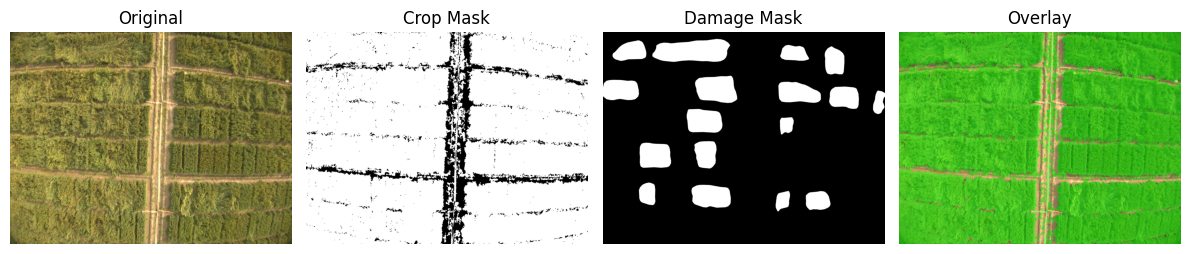

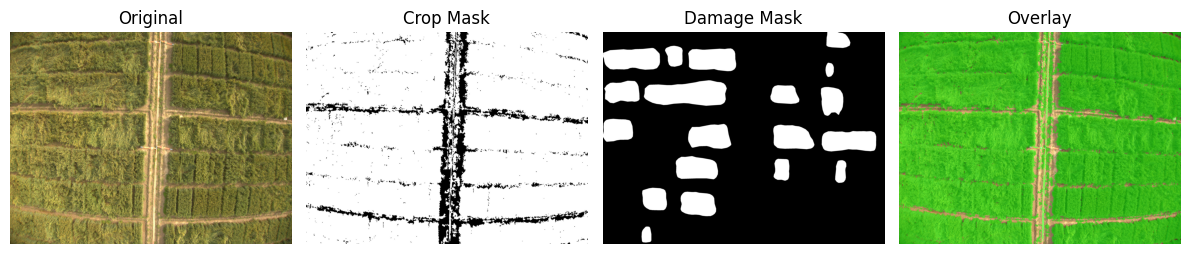

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Output folders
base_path = "/content/output"

orig_dir = os.path.join(base_path, "original")
crop_dir = os.path.join(base_path, "crop_mask")
damage_dir = os.path.join(base_path, "damage_mask")
overlay_dir = os.path.join(base_path, "overlay")

files = os.listdir(orig_dir)


samples = random.sample(files, 2)

for file in samples:

    orig = cv2.cvtColor(cv2.imread(os.path.join(orig_dir, file)), cv2.COLOR_BGR2RGB)
    crop = cv2.imread(os.path.join(crop_dir, file), 0)
    damage = cv2.imread(os.path.join(damage_dir, file), 0)
    overlay = cv2.cvtColor(cv2.imread(os.path.join(overlay_dir, file)), cv2.COLOR_BGR2RGB)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(orig)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Crop Mask")
    plt.imshow(crop, cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Damage Mask")
    plt.imshow(damage, cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

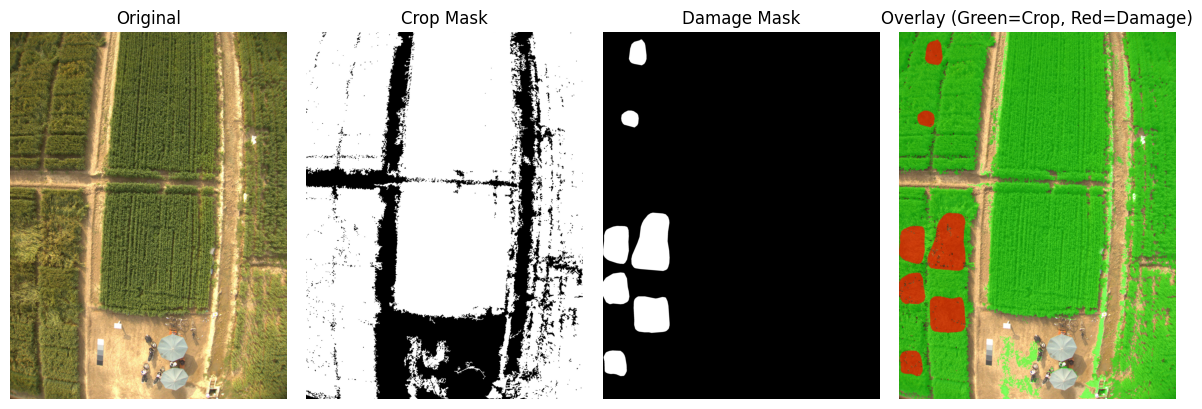

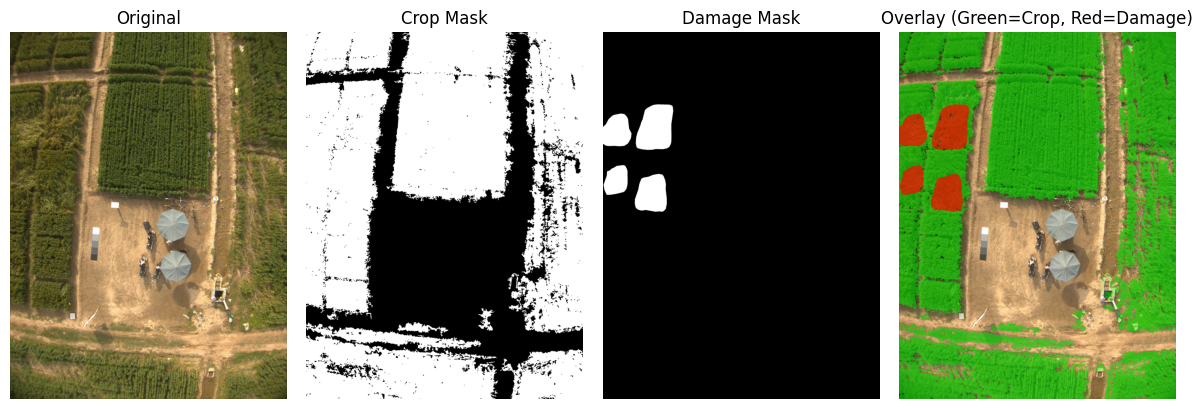

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt


base_path = "/content/output"

orig_dir = os.path.join(base_path, "original")
crop_dir = os.path.join(base_path, "crop_mask")
damage_dir = os.path.join(base_path, "damage_mask")


files = os.listdir(orig_dir)

# Pick 2 random images
samples = random.sample(files, 2)

for file in samples:

    orig = cv2.cvtColor(cv2.imread(os.path.join(orig_dir, file)), cv2.COLOR_BGR2RGB)
    crop = cv2.imread(os.path.join(crop_dir, file), 0)
    damage = cv2.imread(os.path.join(damage_dir, file), 0)


    # GREEN overlay (crop)

    overlay = orig.copy()

    green_layer = np.zeros_like(orig)
    green_layer[:] = [0, 255, 0]

    crop_mask = crop == 255

    overlay[crop_mask] = cv2.addWeighted(
        orig[crop_mask], 0.5,
        green_layer[crop_mask], 0.5,
        0
    )


    # RED overlay (damage ONLY inside crop)

    red_layer = np.zeros_like(orig)
    red_layer[:] = [255, 0, 0]

    damage_mask = (damage == 255) & crop_mask

    overlay[damage_mask] = cv2.addWeighted(
        overlay[damage_mask], 0.3,
        red_layer[damage_mask], 0.7,
        0
    )

    # Plot

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(orig)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Crop Mask")
    plt.imshow(crop, cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Damage Mask")
    plt.imshow(damage, cmap='gray')
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Green=Crop, Red=Damage)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()